In [ ]:
# ── Notebook parameters ─────────────────────────────────────────
# Defaults for interactive use. extract_notebook_figures.py will
# override these via a cell injected right below this one.
#
# Add notebook-level globals here, e.g.:
#     CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-xxxx"
#     CHECKPOINT_FILE = "step_0.pt"


# Functional PCA — Spoken Digit Audio (1-D)

Companion notebook for `fpca.py` trained on **Free Spoken Digit Dataset** (FSDD).

Each audio clip is a 1-D function  $f : [0,1] \to \mathbb{R}$  whose observations
are the raw PCM samples at their natural positions — no interpolation, no padding.
The learned isometry $Q$ diagonalises the covariance operator of this function class;
the pushforward atoms $\{Q\phi_k\}$ are the functional PCA modes.

Sections:
1. Load checkpoint
2. Sample waveforms
3. Learned atoms $Q\phi_k$ vs. Fourier atoms $\phi_k$
4. Learned mean function $\mu(x)$
5. Reconstruction at increasing truncation
6. PCA gold baseline
7. PSNR comparison

In [1]:
%load_ext autoreload
%autoreload 2

import sys, math
sys.path.insert(0, '..')

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from hydra.utils import instantiate

from infidictionary.datasets import IrregularDataset
from infidictionary.datasets.audio import SpokenDigitDataset
from infidictionary.dictionaries import InfiDictionary
from infidictionary.networks import NeuralField
from infidictionary.neural_isometries import NeuralIsometry, IdentityIsometry
from infidictionary.recon import get_reconstructions
from infidictionary.domain_samplers import LineSegmentSampler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


In [2]:
CHECKPOINT_DIR  = '../outputs/checkpoints/wandb-ok5u56xk'   # <-- set this
CHECKPOINT_FILE = 'step_12.pt'                            # <-- set this

with open(f'{CHECKPOINT_DIR}/config.yaml') as f:
    conf = OmegaConf.create(yaml.safe_load(f))

neural_isometry:     NeuralIsometry  = instantiate(conf.neural_isometry).to(device)
mean_function:       NeuralField     = instantiate(conf.mean_function).to(device)
initial_dictionary:  InfiDictionary  = instantiate(conf.initial_dictionary)
function_generator:  SpokenDigitDataset = instantiate(conf.function_generator)

ckpt = torch.load(f'{CHECKPOINT_DIR}/{CHECKPOINT_FILE}', map_location=device, weights_only=False)
neural_isometry.load_state_dict(ckpt['models']['neural_isometry'])
mean_function.load_state_dict(ckpt['models']['mean_function'])

model_state_kwargs = OmegaConf.to_container(conf.get('model_state_kwargs', {'num_steps': 200}), resolve=True)
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval(); mean_function.eval()

pullback_kwargs = OmegaConf.to_container(conf.get('pullback_pushforward_kwargs', {}), resolve=True)

print(f'Loaded  : {CHECKPOINT_DIR}/{CHECKPOINT_FILE}  (epoch {ckpt["epoch"]})')
print(f'Metric  : {ckpt["metric"]:.4f}  |  best: {ckpt["best_metric"]:.4f}')
print(f'Clips   : {function_generator.n_images}  |  sr: {conf.function_generator.target_sr} Hz')

Loaded  : ../outputs/checkpoints/wandb-ok5u56xk/step_12.pt  (epoch 11)
Metric  : 0.0000  |  best: 0.0000
Clips   : 300  |  sr: 8000 Hz


## Shared visualisation grid

Since each clip has its own natural coordinate grid, we evaluate everything on a
dense shared grid for display and PSNR computation.

In [3]:
N_VIS        = 512    # points on the dense display grid
t_vis        = torch.linspace(0.5/N_VIS, 1.0 - 0.5/N_VIS, N_VIS)   # (N_VIS,)
coords_vis   = t_vis.unsqueeze(-1).to(device)                         # (N_VIS, 1)
lad_vis      = torch.zeros(N_VIS, device=device)

t_np = t_vis.numpy()  # for plotting

# Build a dense visualisation tensor of all clips on the shared grid.
# Uses nearest-neighbour lookup (display only — not used in training).
all_clips_vis = torch.stack([
    function_generator.eval_at(t_vis, i) for i in range(function_generator.n_images)
], dim=0).to(device)   # (n_images, N_VIS, 1)

print(f'Display grid: {N_VIS} points  |  clips on grid: {tuple(all_clips_vis.shape)}')

Display grid: 512 points  |  clips on grid: (300, 512, 1)


## Sample waveforms

Raw clips at their natural resolution (variable lengths).

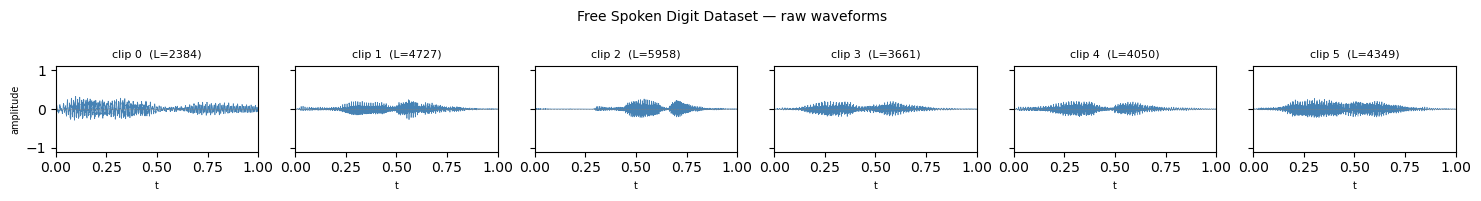

In [4]:
N_SHOW = 6
fig, axes = plt.subplots(1, N_SHOW, figsize=(2.5*N_SHOW, 2.0), sharey=True)
for j, ax in enumerate(axes):
    coords_j, vals_j = function_generator(seed=j)
    t_j = coords_j.squeeze().cpu().numpy()
    v_j = vals_j.squeeze().cpu().numpy()
    ax.plot(t_j, v_j, linewidth=0.5, color='steelblue')
    ax.set_title(f'clip {j}  (L={len(t_j)})', fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(-1.1, 1.1)
    ax.axhline(0, color='grey', linewidth=0.4, linestyle='--')
    ax.set_xlabel('t', fontsize=7)
    if j == 0: ax.set_ylabel('amplitude', fontsize=7)
plt.suptitle('Free Spoken Digit Dataset — raw waveforms', fontsize=10)
plt.tight_layout(); plt.show()

## Fourier atoms and learned atoms

Each Fourier atom $\phi_k$ is a sinusoid; the learned atom $Q\phi_k$ is its
pushed-forward version — these are the functional PCA modes.

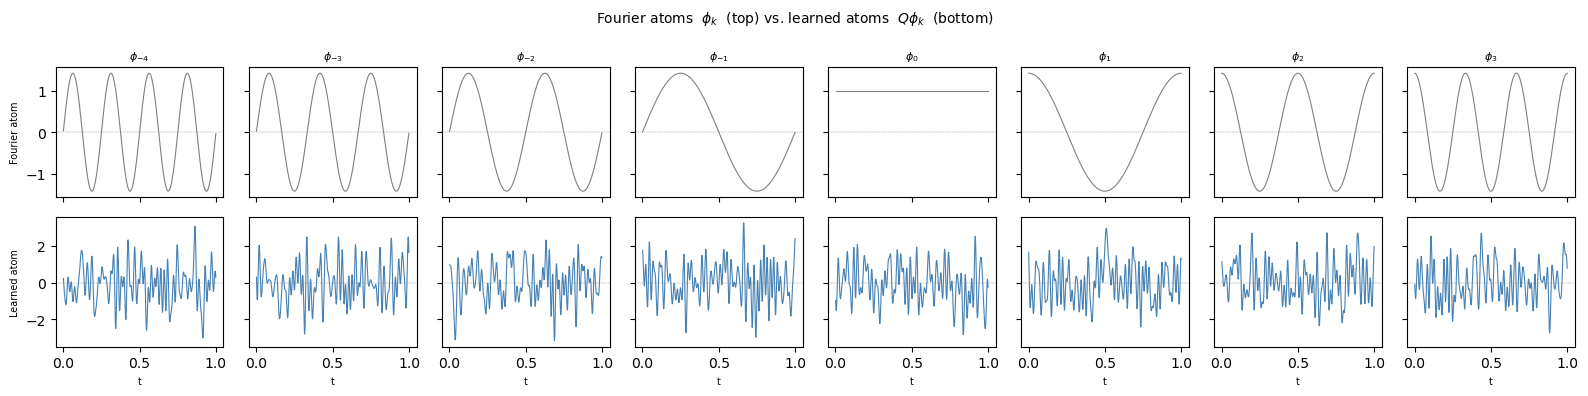

In [5]:
K_ATOMS = 8    # number of atoms to show
indices_show = initial_dictionary.get_truncated_indices(K_ATOMS // 2 + 1).to(device)[:K_ATOMS]

neural_isometry.shuffle_model_state(**model_state_kwargs)
with torch.no_grad():
    atoms_orig   = initial_dictionary.get_atoms(coords_vis, indices_show)   # (K, N, 1)
    _, _, atoms_pushed = neural_isometry.pushforward(
        coords_vis, lad_vis, atoms_orig, **pullback_kwargs
    )                                                                         # (K, N, 1)

fig, axes = plt.subplots(2, K_ATOMS, figsize=(2.0*K_ATOMS, 4.0),
                          sharex=True, sharey='row')
for k in range(K_ATOMS):
    idx_label = tuple(indices_show[k].cpu().tolist())

    ax = axes[0, k]
    ax.plot(t_np, atoms_orig[k, :, 0].cpu().numpy(), linewidth=0.8, color='grey')
    ax.axhline(0, color='grey', linewidth=0.3, linestyle='--')
    ax.set_title(f'$\\phi_{{{idx_label[0]}}}$', fontsize=8)
    if k == 0: ax.set_ylabel('Fourier atom', fontsize=7)

    ax = axes[1, k]
    ax.plot(t_np, atoms_pushed[k, :, 0].cpu().numpy(), linewidth=0.8, color='steelblue')
    ax.axhline(0, color='grey', linewidth=0.3, linestyle='--')
    ax.set_xlabel('t', fontsize=7)
    if k == 0: ax.set_ylabel('Learned atom', fontsize=7)

plt.suptitle('Fourier atoms  $\\phi_k$  (top) vs. learned atoms  $Q\\phi_k$  (bottom)', fontsize=10)
plt.tight_layout(); plt.show()

## Learned mean function

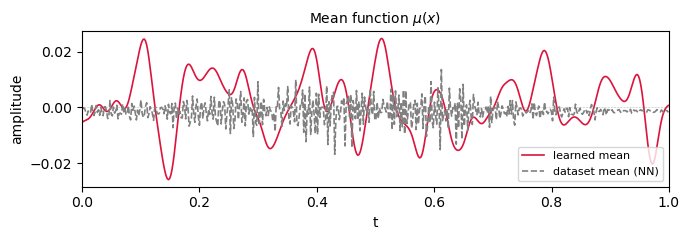

In [6]:
with torch.no_grad():
    mean_vals = mean_function(coords_vis)   # (N_VIS, 1)

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.plot(t_np, mean_vals.squeeze().cpu().numpy(), linewidth=1.2, color='crimson', label='learned mean')

# Overlay dataset mean for comparison
dataset_mean = all_clips_vis.mean(dim=0).squeeze().cpu().numpy()
ax.plot(t_np, dataset_mean, linewidth=1.2, color='grey', linestyle='--', label='dataset mean (NN)')

ax.axhline(0, color='grey', linewidth=0.4, linestyle=':')
ax.set_xlim(0, 1); ax.set_xlabel('t'); ax.set_ylabel('amplitude')
ax.legend(fontsize=8); ax.set_title('Mean function $\\mu(x)$', fontsize=10)
plt.tight_layout(); plt.show()

## Reconstruction at increasing truncation

Each signal is centred, pulled back to Fourier space, truncated to the top-$K$ atoms,
and pushed forward again.

In [7]:
TRUNCATION_LIST = [1, 2, 3, 5, 10, 20]
N_VAL           = 4

val_clips = all_clips_vis[:N_VAL]   # (N_VAL, N_VIS, 1)

identity_isometry = IdentityIsometry().to(device).eval()
neural_isometry.shuffle_model_state(**model_state_kwargs)

fourier_recons, learned_recons = [], []
n_atoms_list = []
with torch.no_grad():
    for trunc in TRUNCATION_LIST:
        n_atoms_list.append(initial_dictionary.get_truncated_indices(trunc).shape[0])
        fourier_recons.append(get_reconstructions(
            coords=coords_vis, functions=val_clips,
            neural_isometry=identity_isometry, mean_function=mean_function,
            dictionary=initial_dictionary, truncation_factor=trunc, **pullback_kwargs,
        ).cpu())
        learned_recons.append(get_reconstructions(
            coords=coords_vis, functions=val_clips,
            neural_isometry=neural_isometry, mean_function=mean_function,
            dictionary=initial_dictionary, truncation_factor=trunc, **pullback_kwargs,
        ).cpu())

val_clips_cpu = val_clips.cpu()
print(f'Truncations: {TRUNCATION_LIST}  →  atoms: {n_atoms_list}')

Truncations: [1, 2, 3, 5, 10, 20]  →  atoms: [1, 3, 5, 9, 19, 39]


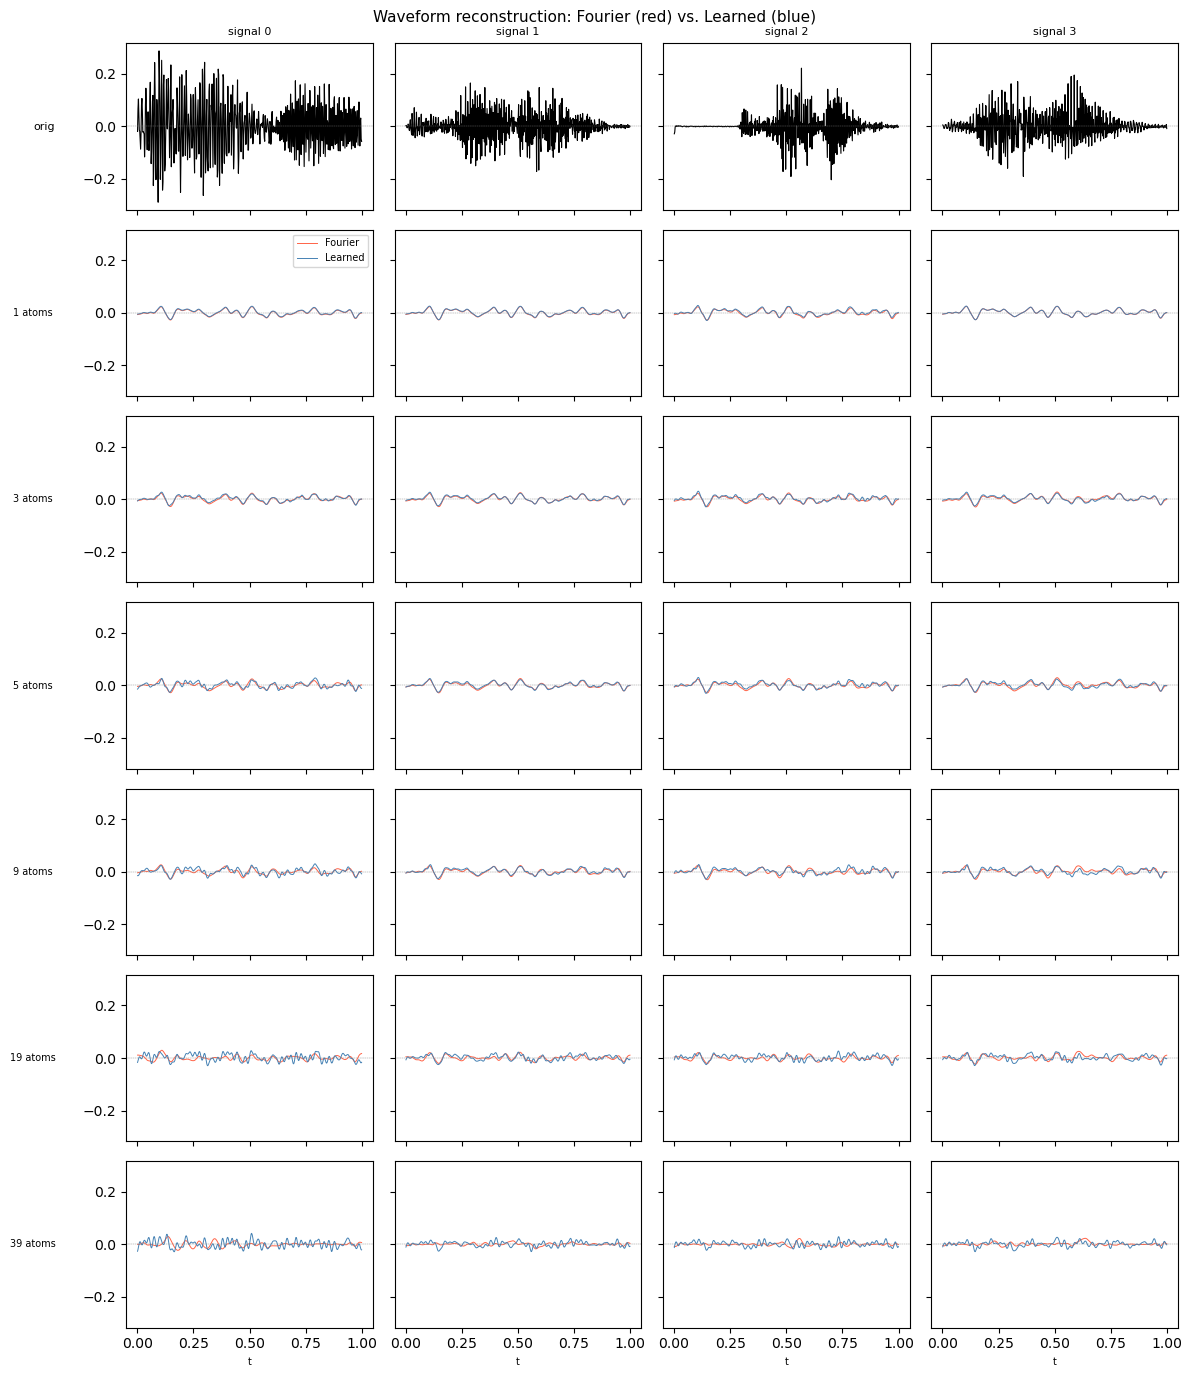

In [8]:
colors = {'orig': 'black', 'Fourier': 'tomato', 'Learned': 'steelblue'}

fig, axes = plt.subplots(len(TRUNCATION_LIST) + 1, N_VAL,
                          figsize=(3.0*N_VAL, 2.0*(len(TRUNCATION_LIST)+1)),
                          sharex=True, sharey=True)

# Row 0: originals
for l in range(N_VAL):
    axes[0, l].plot(t_np, val_clips_cpu[l, :, 0].numpy(), color=colors['orig'], lw=0.8)
    axes[0, l].set_title(f'signal {l}', fontsize=8)
    axes[0, l].axhline(0, color='grey', lw=0.3, ls='--')
axes[0, 0].set_ylabel('orig', fontsize=8, rotation=0, labelpad=28, va='center')

# Rows 1+: reconstructions at each truncation
for k, (fourer_r, learned_r, n_atoms) in enumerate(zip(fourier_recons, learned_recons, n_atoms_list)):
    for l in range(N_VAL):
        ax = axes[k + 1, l]
        ax.plot(t_np, fourer_r[l, :, 0].numpy(), color=colors['Fourier'], lw=0.7,
                label='Fourier' if l == 0 else '_')
        ax.plot(t_np, learned_r[l, :, 0].numpy(), color=colors['Learned'], lw=0.7,
                label='Learned' if l == 0 else '_')
        ax.axhline(0, color='grey', lw=0.3, ls='--')
    axes[k + 1, 0].set_ylabel(f'{n_atoms} atoms', fontsize=7, rotation=0, labelpad=36, va='center')

axes[1, 0].legend(fontsize=7, loc='upper right')
for l in range(N_VAL):
    axes[-1, l].set_xlabel('t', fontsize=7)

plt.suptitle('Waveform reconstruction: Fourier (red) vs. Learned (blue)', fontsize=11)
plt.tight_layout(); plt.show()

## PCA gold baseline

Classical PCA on the shared dense grid (nearest-neighbour evaluation — only for baseline comparison).

   K  cumvar
   1    3.5%
   3    9.7%
   5   15.2%
  10   26.7%
  20   43.7%


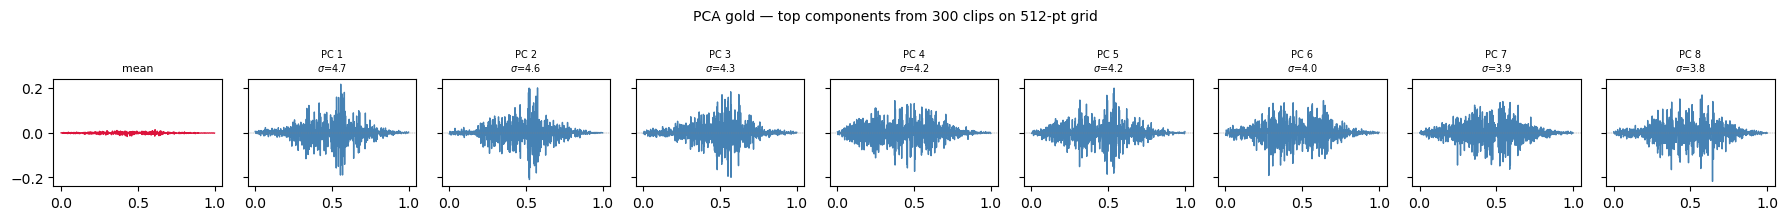

In [9]:
X_flat  = all_clips_vis.squeeze(-1).cpu().float()       # (M, N_VIS)
M, N    = X_flat.shape
mean_flat = X_flat.mean(dim=0)                           # (N_VIS,)
X_c     = X_flat - mean_flat
_, S, Vh = torch.linalg.svd(X_c, full_matrices=False)

ev = (S**2) / (S**2).sum()
print(f'{'K':>4}  cumvar')
for k in [1, 3, 5, 10, 20]:
    if k <= len(S):
        print(f'{k:>4}  {ev[:k].sum()*100:5.1f}%')

# Show top PCA modes
K_SHOW = min(8, Vh.shape[0])
fig, axes = plt.subplots(1, K_SHOW + 1, figsize=(2.0*(K_SHOW+1), 2.2), sharey=True)
axes[0].plot(t_np, mean_flat.numpy(), color='crimson', lw=1.0)
axes[0].set_title('mean', fontsize=8)
for i in range(K_SHOW):
    axes[i+1].plot(t_np, Vh[i].numpy(), color='steelblue', lw=1.0)
    axes[i+1].set_title(f'PC {i+1}\n$\\sigma$={S[i]:.1f}', fontsize=7)
    axes[i+1].axhline(0, color='grey', lw=0.3, ls='--')
plt.suptitle(f'PCA gold — top components from {M} clips on {N_VIS}-pt grid', fontsize=10)
plt.tight_layout(); plt.show()

In [10]:
# PCA reconstructions at the same truncation levels
mean_dev = mean_flat.to(device)
pca_recons = []
for n_atoms in n_atoms_list:
    k     = min(n_atoms, Vh.shape[0])
    comps = Vh[:k].to(device)
    flat  = val_clips.squeeze(-1)                  # (N_VAL, N_VIS)
    coeff = (flat - mean_dev) @ comps.T
    pca_recons.append((coeff @ comps + mean_dev).unsqueeze(-1).cpu())  # (N_VAL, N_VIS, 1)

# PSNR table
def psnr(a, b, peak=1.0):
    mse = (a - b).pow(2).mean().item()
    return 10 * math.log10(peak**2 / (mse + 1e-12))

print(f'{'n_atoms':>8}  {'Fourier':>8}  {'Learned':>8}  {'PCA-gold':>10}')
print('-' * 40)
for i, n_atoms in enumerate(n_atoms_list):
    f_psnr = np.mean([psnr(fourier_recons[i][l], val_clips_cpu[l]) for l in range(N_VAL)])
    l_psnr = np.mean([psnr(learned_recons[i][l], val_clips_cpu[l]) for l in range(N_VAL)])
    p_psnr = np.mean([psnr(pca_recons[i][l],    val_clips_cpu[l]) for l in range(N_VAL)])
    print(f'{n_atoms:>8}  {f_psnr:>8.1f}  {l_psnr:>8.1f}  {p_psnr:>10.1f}')

 n_atoms   Fourier   Learned    PCA-gold
----------------------------------------
       1      24.8      24.8        25.1
       3      24.8      24.8        25.1
       5      24.8      24.8        25.2
       9      24.8      24.8        25.3
      19      24.9      24.9        25.6
      39      25.0      24.9        26.4
